In [29]:
#import the libraries
import pandas as pd #for manipulation
import numpy as np  #for manipulation
from sklearn.ensemble import RandomForestRegressor  #An estimator for regression
from sklearn.model_selection import train_test_split #for spliting data
from sklearn import metrics #for evaluation
from sklearn.preprocessing import LabelEncoder #use to convert text to numbers)

In [30]:
#import the dataset
data = pd.read_csv("Medical_cost.csv")
data.head()

,age,sex,bmi,children,smoker,region,medical charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
data.shape

(1338, 7)

In [32]:
#NOTE: machine Learning does not work with missing data
# check for missing data.
#data.isnull().sum()  OR
data.isnull


<bound method DataFrame.isnull of       age     sex     bmi  children smoker     region  medical charges
0      19  female  27.900         0    yes  southwest      16884.92400
1      18    male  33.770         1     no  southeast       1725.55230
2      28    male  33.000         3     no  southeast       4449.46200
3      33    male  22.705         0     no  northwest      21984.47061
4      32    male  28.880         0     no  northwest       3866.85520
...   ...     ...     ...       ...    ...        ...              ...
1333   50    male  30.970         3     no  northwest      10600.54830
1334   18  female  31.920         0     no  northeast       2205.98080
1335   18  female  36.850         0     no  southeast       1629.83350
1336   21  female  25.800         0     no  southwest       2007.94500
1337   61  female  29.070         0    yes  northwest      29141.36030

[1338 rows x 7 columns]>

In [33]:
# check for missing data.(another method)
data.isna().sum()

age                0
sex                0
bmi                0
children           0
smoker             0
region             0
medical charges    0
dtype: int64

In [34]:
data.dtypes

age                  int64
sex                 object
bmi                float64
children             int64
smoker              object
region              object
medical charges    float64
dtype: object

In [35]:
#count of children (counting the number of children)
data.children.value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [36]:
#count of region
data.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [37]:
# transforming sex(text) to sex(numbers)
encoder = LabelEncoder()
labels = encoder.fit_transform(data.sex)
data['sex'] = labels
data.head()

,age,sex,bmi,children,smoker,region,medical charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [38]:
labels

array([0, 1, 1, ..., 0, 0, 0])

In [39]:
# transforming smoker(text) to smoker(numbers)
encoder = LabelEncoder()
labels = encoder.fit_transform(data.smoker)
data['smoker'] = labels
data.head()

,age,sex,bmi,children,smoker,region,medical charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [40]:
# transforming region(text) to region(numbers)
encoder = LabelEncoder()
labels = encoder.fit_transform(data.region)
data['region'] = labels
data.head()

,age,sex,bmi,children,smoker,region,medical charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [41]:
# 0=northeast, 1=northwest, 2=southwest and  3=southeast
data.region.value_counts()

region
2    364
3    325
1    325
0    324
Name: count, dtype: int64

In [42]:
#aixs=0 is row, axis=1 is the column
#define x and y
X = data.drop('medical charges',axis=1)
X.head(2)

,age,sex,bmi,children,smoker,region
0,19,0,27.90,0,1,3
1,18,1,33.77,1,0,2


In [43]:
y = data ['medical charges']
y.head(2)

0    16884.9240
1     1725.5523
Name: medical charges, dtype: float64

In [44]:
#split the data into train and test set
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size = 0.2, random_state =42)

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1070, 6), (268, 6), (1070,), (268,))

In [46]:
# fit the model and use it to make predictions
model = RandomForestRegressor()

In [47]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [48]:
#evaluate the model
test_data_prediction = model.predict(X_test)
score = metrics.r2_score(y_test,test_data_prediction)
print(score)

0.8668498027531352


In [49]:
print(f"the acccuracy score is {score:.2f}%")

the acccuracy score is 0.87%


In [50]:
import pickle 
filename = 'medical_cost_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [51]:
load_model = pickle.load(open('model.pkl', 'rb'))

In [52]:
New_data = [50,1,20.44,0,0,2]

prediction = load_model.predict([New_data])
prediction

In [53]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


# Feature selection

In [54]:
importance = model.feature_importances_
importance_data = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
}).sort_values(by="Importance",
               ascending=False)

In [55]:
importance_data

,Feature,Importance
4,smoker,0.612334
2,bmi,0.212698
0,age,0.133135
3,children,0.020918
5,region,0.014163
1,sex,0.006751


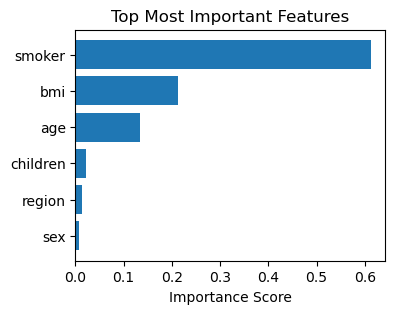

In [56]:
import matplotlib.pyplot as plt
feature_ranking = importance_data
plt.figure(figsize=(4,3))
plt.barh(feature_ranking["Feature"], feature_ranking["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Most Important Features")
plt.xlabel("Importance Score")
plt.show()